# Exploratory Data Analysis

### 1. Import các thư viện cần thiết, load dataset và ghi lại các observation được thu từ vị trí nào

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

data = pd.read_csv("../data/cleaned/data-cleaned.csv")

l1_data = data[data['distance_m'] == 1].copy()  #Location 1 - Vị trí thu gần nhất
l1_y = l1_data['throughput_down_mbps']

l2_data = data[data['distance_m'] == 15].copy() #Location 2 - Vị trí thu xa nhất
l2_y = l2_data['throughput_down_mbps']

l3_data = data[data['distance_m'] == 5].copy()  #Location 3 - Vị trí thu trung bình
l3_y = l3_data['throughput_down_mbps']

display(data)

,seconds_since_midnight,distance_m,signal_mean_pct,signal_std_pct,rx_link_rate_mean,tx_link_rate_mean,rtt_mean_ms,rtt_std_ms,jitter_ms,packet_loss_pct,throughput_down_mbps
0,58515,1,79.416667,0.514929,866.7,866.700000,1.100000,0.316228,0.222222,0.0,94.402610
1,58536,1,80.000000,0.000000,866.7,866.700000,1.800000,2.529822,0.888889,0.0,94.365150
2,58557,1,80.000000,0.000000,866.7,866.700000,2.666667,4.636809,1.750000,10.0,94.672873
3,58583,1,80.000000,0.000000,866.7,866.700000,1.555556,1.333333,1.125000,10.0,93.968420
4,58608,1,81.000000,0.000000,866.7,866.700000,3.800000,4.732864,4.222222,0.0,94.647882
...,...,...,...,...,...,...,...,...,...,...,...
355,33608,15,34.750000,1.544786,1.0,6.500000,459.900000,542.296649,450.777778,0.0,0.104711
356,33645,15,34.000000,1.477098,1.0,7.041667,576.700000,358.224960,375.111111,0.0,0.000000
357,33671,15,34.000000,1.477098,1.0,6.500000,485.700000,481.156258,464.888889,0.0,0.104701
358,33701,15,33.500000,2.504541,1.0,7.583333,192.400000,173.633202,253.444444,0.0,0.000000


### 2. Tổng quan của 7 biến chính trong dataset

In [22]:
exclude_columns_2 = ["signal_std_pct", "rtt_std_ms"]
numeric_data = data.select_dtypes(include="number").drop(columns=exclude_columns_2, errors="ignore")

overview = pd.DataFrame({
    "Min": numeric_data.min(),
    "Max": numeric_data.max(),
    "Mean": numeric_data.mean(),
    "Median": numeric_data.median(),
    "StdDev": numeric_data.std()
})

display(overview.round(2))

,Min,Max,Mean,Median,StdDev
seconds_since_midnight,28122.0,72116.00,53694.01,54439.00,15243.77
distance_m,1.0,15.00,7.00,5.00,5.90
signal_mean_pct,21.0,95.00,67.72,84.00,25.94
rx_link_rate_mean,1.0,866.70,337.47,144.40,379.28
tx_link_rate_mean,6.5,866.70,339.70,144.40,377.32
rtt_mean_ms,1.0,1577.10,134.48,3.11,263.16
jitter_ms,0.0,1428.00,134.36,3.56,250.26
packet_loss_pct,0.0,20.00,1.70,0.00,4.12
throughput_down_mbps,0.0,94.84,55.41,82.20,42.53


#### Nhận xét
- Có khác biệt lớn giữa `Mean` và `Median` của nhiều biến

→ Cần kiểm tra sự phân bố của các biến
- `rtt_mean_ms` và `jitter_ms` có giá trị `Max` lớn hơn `Mean` và `Median` nhiều lần

→ Có các quan sát bất thường của hai biến này

 ### 3. Tìm các quan sát có dữ liệu trống (N/A)

In [23]:
display(data[data.isna().any(axis=1)])

,seconds_since_midnight,distance_m,signal_mean_pct,signal_std_pct,rx_link_rate_mean,tx_link_rate_mean,rtt_mean_ms,rtt_std_ms,jitter_ms,packet_loss_pct,throughput_down_mbps
332,33156,15,35.25,1.356801,1.0,6.500000,NaN,NaN,NaN,NaN,0.0
349,33466,15,31.75,5.344921,1.0,10.291667,NaN,NaN,NaN,NaN,0.0


#### Nhận xét
- Dữ liệu trống xuất hiện ở các biến:
  - `rtt_mean_ms`
  - `rtt_std_ms`
  - `jitter_ms`
  - `packet_loss_pct`

→ Dữ liệu trống sẽ được xử lý ở bước Preprocessing

### 4. Các biểu đồ phân bố của các biến

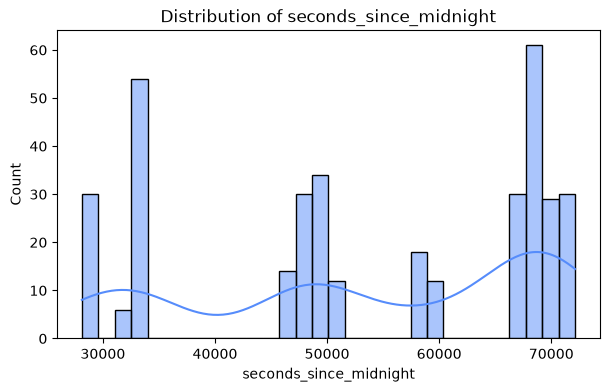

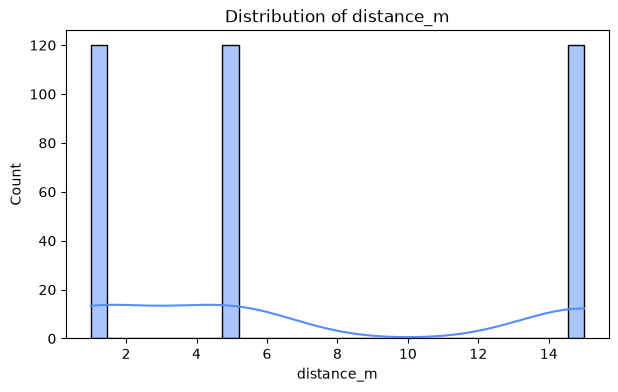

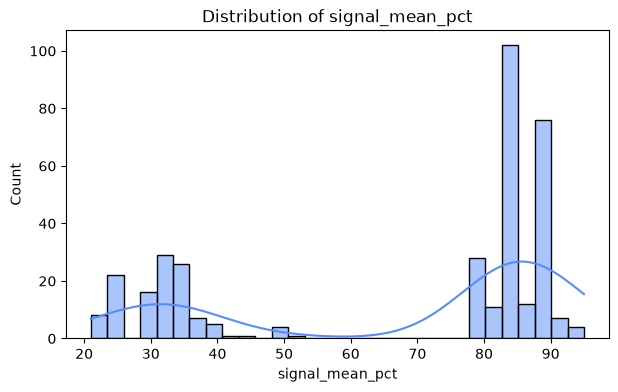

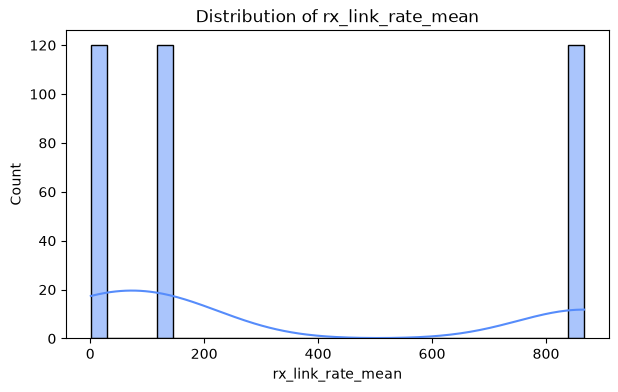

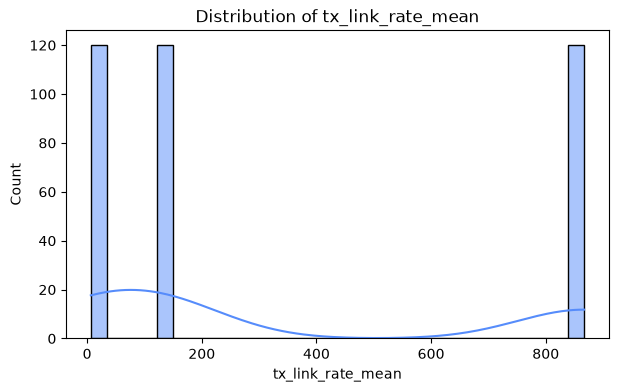

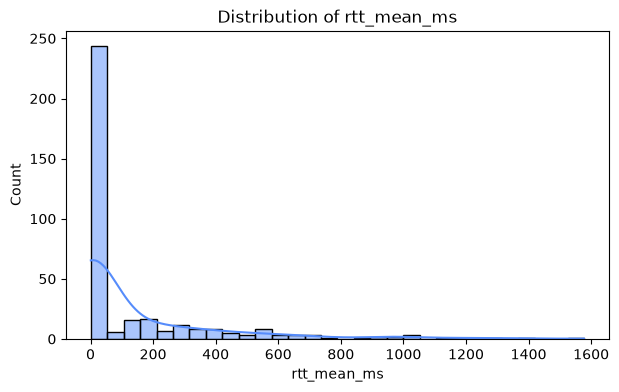

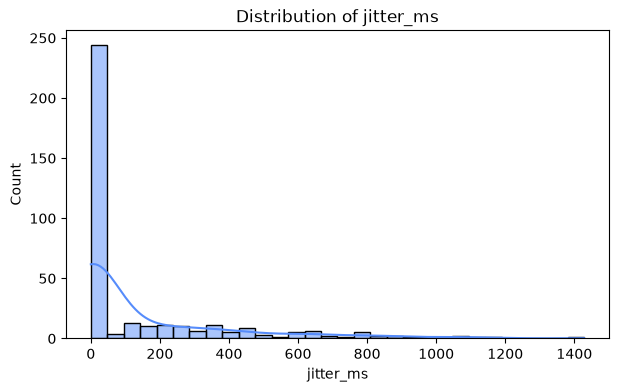

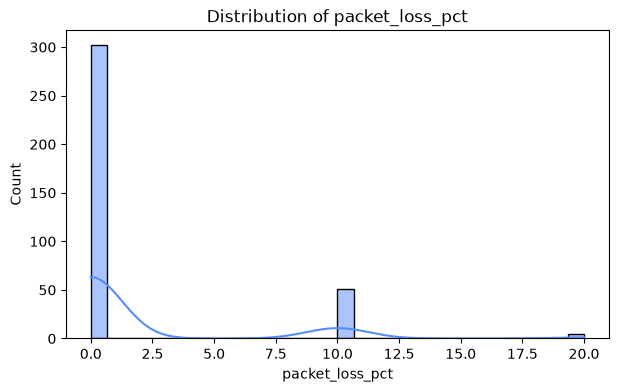

In [24]:
network_features = [
    "seconds_since_midnight",
    "distance_m",
    "signal_mean_pct",
    "rx_link_rate_mean",
    "tx_link_rate_mean",
    "rtt_mean_ms",
    "jitter_ms",
    "packet_loss_pct"
]


for col in network_features:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=data,
        x=col,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

#### Nhận xét
- `signal_mean_pct` tập trung ở hai mức: từ hơn 20% đến 40% và từ gần 80% đến hơn 90%.
- `distance_m`, `rx_link_rate_mean` và `tx_link_rate_mean` đều phân hóa thành 3 mức rõ rệt.
- `rtt_mean_ms`, `jitter_ms` và `packet_loss_pct` chủ yếu có giá trị thấp.

### 5. Ma trận tương quan

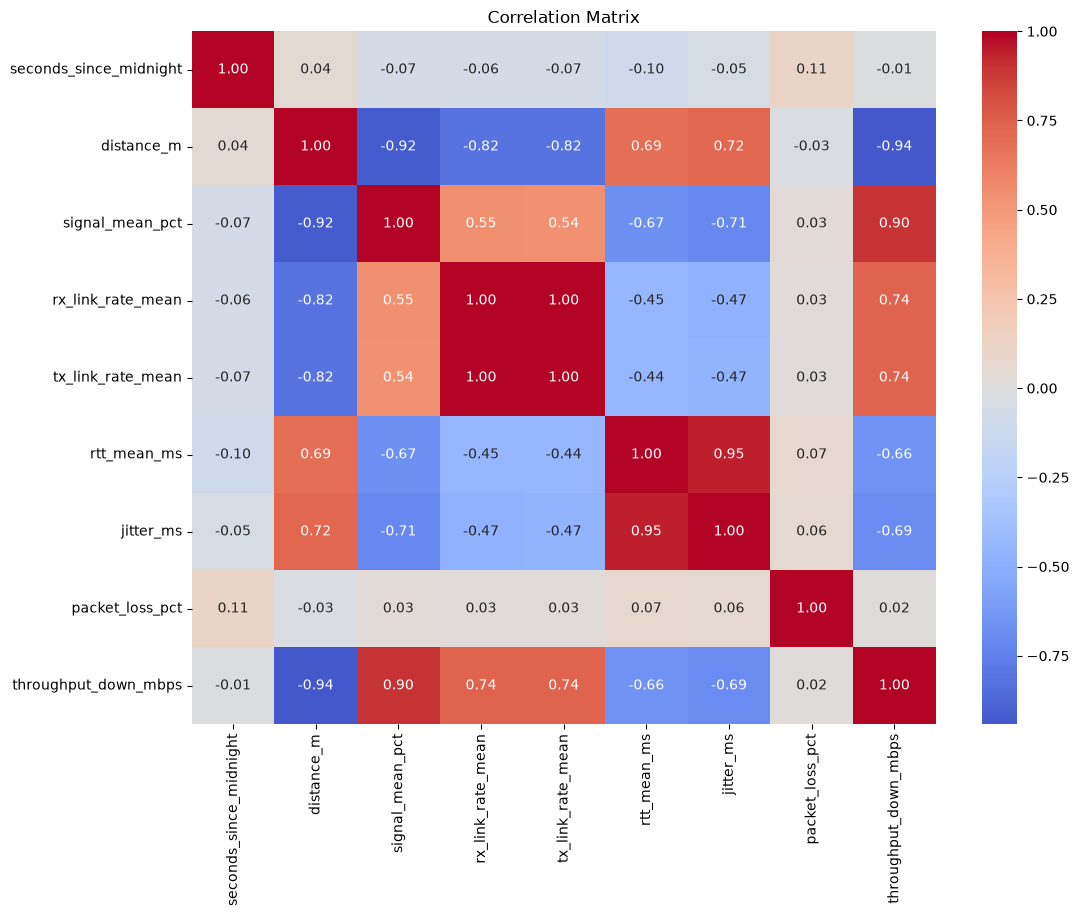

In [32]:
exclude_columns_5 = ["signal_std_pct", "rtt_std_ms"]

corr = (
    data
    .select_dtypes(include=np.number)
    .drop(columns=exclude_columns_5, errors="ignore")
    .corr()
)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)


plt.title("Correlation Matrix")
plt.savefig("../media/02_05.png", dpi=300, bbox_inches='tight')
plt.show()

#### Nhận xét
- Các biến `signal_mean_pct`, `rx_link_rate_ms`, và `tx_link_rate_ms` có quan hệ tương quan dương với `throughput_down_mbps`. Tuy nhiên, hai biến `rx_link_rate` và `tx_link_rate` có quan hệ tương quan 100%

→ Sử dụng các biến `signal_mean_pct` và `rx_link_rate` trong mô hình. `tx_link_rate` sẽ được thể hiện bởi `rx_link_rate` từ đây trở đi
- Các biến `distance_m`, `rtt_mean_ms`, và `jitter_ms` có quan hệ tương quan âm với `throughput_down_mbps`

→ Sử dụng các biến này trong mô hình
- Các biến `seconds_since_midnight`, và `packet_loss_pct` có quan hệ tương quan rất yếu với `throughput_down_mbps`

→ Không sử dụng hai biến này trong mô hình

### 6. Mối quan hệ Signal vs Throughput

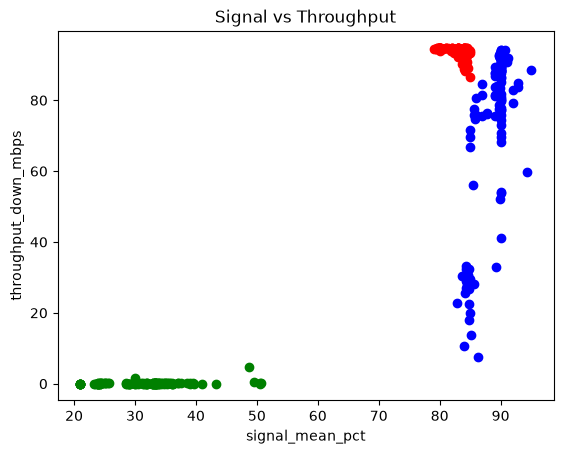

In [33]:
l1_X_signal_mean = l1_data[['signal_mean_pct']]
l2_X_signal_mean = l2_data[['signal_mean_pct']]
l3_X_signal_mean = l3_data[['signal_mean_pct']]

plt.figure(0)
plt.title("Signal vs Throughput")
plt.xlabel("signal_mean_pct")
plt.ylabel("throughput_down_mbps")

plt.scatter(l1_X_signal_mean, l1_y, c='red')
plt.scatter(l2_X_signal_mean, l2_y, c='green')
plt.scatter(l3_X_signal_mean, l3_y, c='blue')

plt.savefig("../media/02_06.png", dpi=300, bbox_inches='tight')
plt.show()

#### Nhận xét
- `throughput_down_mbps` có xu hướng tăng khi `signal_mean_pct` tăng
- Tuy nhiên:
    - Tại mức `signal_mean_pct` trong khoảng 80% đến 90%, `throughput_down_mbps` chia thành hai nhóm: nhóm dưới 40 Mbps và nhóm từ 60 đến hơn 90 Mbps
    - Có trường hợp `signal_mean_pct` cao nhưng `throughput_down_mbps` dưới 10 Mbps

→ `signal_mean_pct` cao không tương đương với `throughput_down_mbps` cao

### 7. Mối quan hệ Link rate vs Throughput

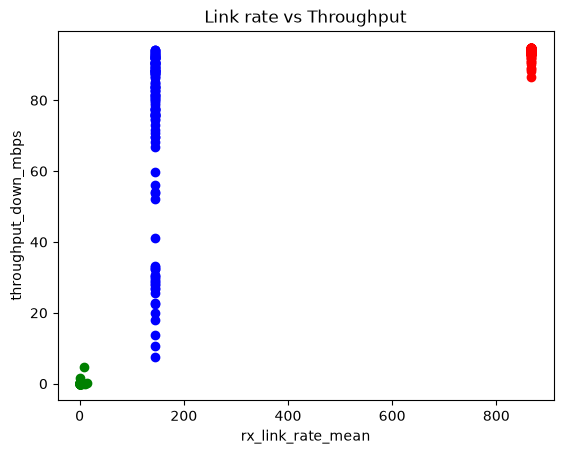

In [34]:
l1_X_link_rate = l1_data[['rx_link_rate_mean']]
l2_X_link_rate = l2_data[['rx_link_rate_mean']]
l3_X_link_rate = l3_data[['rx_link_rate_mean']]

plt.figure(0)
plt.title("Link rate vs Throughput")
plt.xlabel("rx_link_rate_mean")
plt.ylabel("throughput_down_mbps")

plt.scatter(l1_X_link_rate, l1_y, c='red')
plt.scatter(l2_X_link_rate, l2_y, c='green')
plt.scatter(l3_X_link_rate, l3_y, c='blue')

plt.savefig("../media/02_07.png", dpi=300, bbox_inches='tight')
plt.show()

#### Nhận xét
- `throughput_down_mbps` có xu hướng tăng khi `rx_link_rate_mean` tăng
- `rx_link_rate_mean` phân hóa rõ rệt theo vị trí thu, và từ đó ảnh hưởng đến `throughput_down_mbps`

### 8. Mối quan hệ RTT vs Throughput

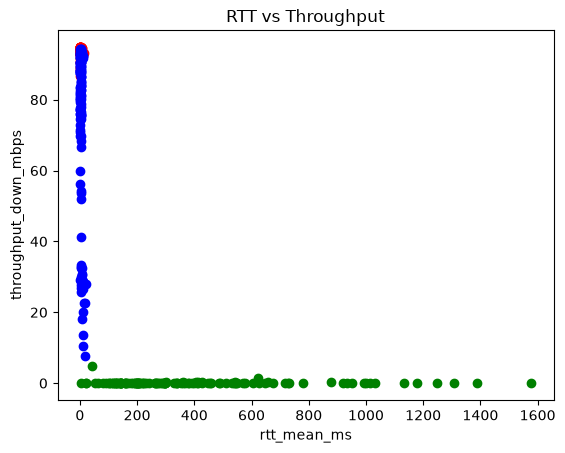

In [35]:
l1_X_rtt_mean_ms = l1_data[['rtt_mean_ms']]
l2_X_rtt_mean_ms = l2_data[['rtt_mean_ms']]
l3_X_rtt_mean_ms = l3_data[['rtt_mean_ms']]

plt.figure(0)
plt.title("RTT vs Throughput")
plt.xlabel("rtt_mean_ms")
plt.ylabel("throughput_down_mbps")

plt.scatter(l1_X_rtt_mean_ms, l1_y, c='red')
plt.scatter(l2_X_rtt_mean_ms, l2_y, c='green')
plt.scatter(l3_X_rtt_mean_ms, l3_y, c='blue')

plt.savefig("../media/02_08.png", dpi=300, bbox_inches='tight')
plt.show()

#### Nhận xét
- `throughput_down_mbps` hầu như chỉ biến thiên ở mức `rtt_mean_ms` rất thấp
- Ở hai địa điểm có khoảng cách gần và trung bình, `rtt_mean_ms` giữ ở mức rất thấp

### 9. Mối quan hệ Jitter và Throughput

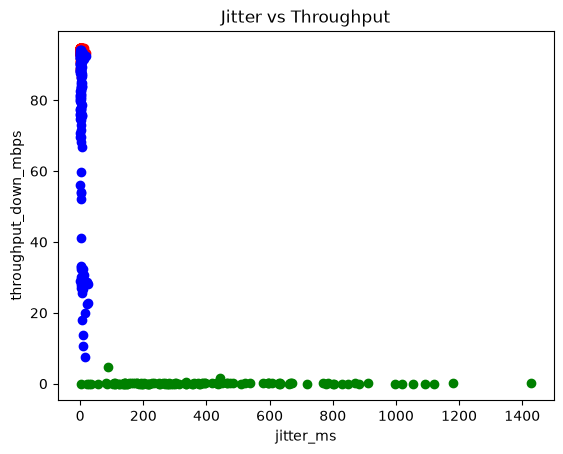

In [36]:
l1_X_jitter_ms = l1_data[['jitter_ms']]
l2_X_jitter_ms = l2_data[['jitter_ms']]
l3_X_jitter_ms = l3_data[['jitter_ms']]

plt.figure(0)
plt.title("Jitter vs Throughput")
plt.xlabel("jitter_ms")
plt.ylabel("throughput_down_mbps")

plt.scatter(l1_X_jitter_ms, l1_y, c='red')
plt.scatter(l2_X_jitter_ms, l2_y, c='green')
plt.scatter(l3_X_jitter_ms, l3_y, c='blue')

plt.savefig("../media/02_09.png", dpi=300, bbox_inches='tight')
plt.show()

#### Nhận xét
- `throughput_down_mbps` hầu như chỉ biến thiên ở mức `jitter_ms` rất thấp
- Ở hai địa điểm có khoảng cách gần và trung bình, `jitter_ms` giữ ở mức rất thấp

### 10. Mối quan hệ Packet loss và Throughput

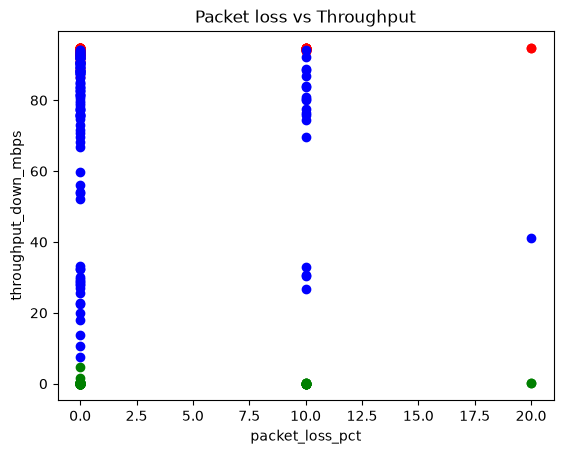

In [37]:
l1_X_packet_loss_pct = l1_data[['packet_loss_pct']]
l2_X_packet_loss_pct = l2_data[['packet_loss_pct']]
l3_X_packet_loss_pct = l3_data[['packet_loss_pct']]

plt.figure(0)
plt.title("Packet loss vs Throughput")
plt.xlabel("packet_loss_pct")
plt.ylabel("throughput_down_mbps")

plt.scatter(l1_X_packet_loss_pct, l1_y, c='red')
plt.scatter(l2_X_packet_loss_pct, l2_y, c='green')
plt.scatter(l3_X_packet_loss_pct, l3_y, c='blue')

plt.savefig("../media/02_10.png", dpi=300, bbox_inches='tight')
plt.show()

#### Nhận xét
- `throughput_down_mbps` biến thiên ở mọi mức `packet_loss_pct`
- Cả ba vị trí thu thập dữ liệu đều đạt các mức `packet_loss_pct` thấp, trung bình và cao

### Nhận xét chung
- Biến khoảng cách `distance_m` có sự tương quan với nhiều biến đầu vào khác

→ Trong quá trình chia dataset thành hai phần: train và test, `distance_m` sẽ cần được stratify (đảm bảo tỷ lệ công bằng cho các vị trí giữa phần train và phần test) để đảm bảo khả năng dự đoán của mô hình ở cả ba vị trí, tức với cả 3 giá trị của `distance_m`